# Step 1 & 2: Cybersecurity and Core Modeling
This notebook loads HR data, applies **Privacy by Design** measures (pseudonymization and removal of PII), and then prepares the data to train a Machine Learning model.

In [1]:
import pandas as pd
import hashlib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the dataset
df = pd.read_csv('archive/HRDataset_v14.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


## Dataset Dictionary — Variable Descriptions

| Variable | Type | Description |
|---|---|---|
| `Employee_Name` | PII | Full name of the employee *(pseudonymized before use)* |
| `EmpID` | PII | Unique numeric employee identifier *(pseudonymized before use)* |
| `DOB` | PII | Date of birth *(dropped — direct re-identification risk)* |
| `Salary` | Numeric | Annual gross salary in USD |
| `Termd` | **Target (0/1)** | **1 = employee has left the company, 0 = still active** |
| `Sex` | Protected | Employee gender: M / F |
| `RaceDesc` | Protected | Employee's self-declared racial/ethnic group (e.g., White, Black or African American, Hispanic) |
| `MaritalDesc` | Categorical | Marital status: Single, Married, Divorced, Widowed, Separated |
| `MaritalStatusID` | Numeric | Numeric encoding of `MaritalDesc` |
| `MarriedID` | Binary | 1 = Married, 0 = Not married |
| `GenderID` | Binary | Numeric encoding of `Sex` (0 = Female, 1 = Male) |
| `CitizenDesc` | Categorical | Citizenship status: US Citizen, Eligible NonCitizen, Non-Citizen |
| `HispanicLatino` | Binary | Yes / No — whether the employee identifies as Hispanic or Latino |
| `Department` | Categorical | Business department the employee belongs to (e.g., Production, IT/IS, Sales) |
| `DeptID` | Numeric | Numeric encoding of `Department` |
| `Position` | Categorical | Job title / role of the employee |
| `PositionID` | Numeric | Numeric encoding of `Position` |
| `State` | Categorical | US state of the employee's address |
| `Zip` | Categorical | Zip code of the employee's address |
| `ManagerID` | Numeric | Unique identifier of the employee's direct manager |
| `ManagerName` | PII | Name of the direct manager *(dropped — indirect re-identification risk)* |
| `RecruitmentSource` | Categorical | Where the employee was recruited from (e.g., LinkedIn, Indeed, Employee Referral) |
| `DateofHire` | Date | Date the employee joined the company *(dropped — not predictive without tenure calculation)* |
| `DateofTermination` | Date | Date the employee left *(dropped — future leakage)* |
| `TermReason` | Text | Stated reason for leaving (e.g., "career change", "hours") *(dropped — future leakage)* |
| `EmploymentStatus` | Categorical | Current employment status: Active / Voluntarily Terminated / Terminated for Cause *(dropped — **direct leakage** of target variable)* |
| `EmpStatusID` | Numeric | Numeric encoding of `EmploymentStatus` *(dropped — **direct leakage**)* |
| `PerformanceScore` | Categorical | Latest performance review rating: Exceeds / Fully Meets / Needs Improvement / PIP |
| `PerfScoreID` | Numeric | Numeric encoding of `PerformanceScore` |
| `EngagementSurvey` | Float (1–5) | Score from company engagement survey — measures how connected the employee feels to the company |
| `EmpSatisfaction` | Int (1–5) | Self-reported employee satisfaction score |
| `SpecialProjectsCount` | Numeric | Number of special projects the employee participated in — proxy for recognition and challenge |
| `LastPerformanceReview_Date` | Date | Date of the most recent annual performance review *(dropped — not comparable across employees without normalisation)* |
| `DaysLateLast30` | Numeric | Number of times the employee arrived late in the last 30 days — proxy for disengagement |
| `Absences` | Numeric | Total number of absences recorded — key signal for disengagement or health issues |
| `FromDiversityJobFairID` | Binary | 1 = Employee was recruited via a diversity job fair |

## Step 1: Cybersecurity & Privacy by Design
To protect the sensitive data of our employees (PII), we will:
1. **Hash** the identifiers and names (using SHA-256) to make re-identification difficult.
2. **Remove** dates of birth (`DOB`) and other metadata that could confidently reveal employees' identities.
3. **Remove** departure reasons to avoid biasing the model (data leakage).

In [2]:
def hash_pii(text):
    if pd.isna(text):
        return text
    return hashlib.sha256(str(text).encode('utf-8')).hexdigest()[:15]

# Pseudonymization
df_secure = df.copy()
df_secure['EmpID_Hash'] = df_secure['EmpID'].apply(hash_pii)
df_secure['Employee_Name_Hash'] = df_secure['Employee_Name'].apply(hash_pii)

# Remove cleartext PII and future variables (preventing data leakage)
cols_to_drop = ['Employee_Name', 'EmpID', 'DOB', 'DateofTermination', 'TermReason', 'ManagerName']
df_secure = df_secure.drop(columns=cols_to_drop, errors='ignore')

print("Preview of secure data ready for AI:\n")
df_secure[['EmpID_Hash', 'Sex', 'Salary', 'Department', 'Termd']].head()

Preview of secure data ready for AI:



,EmpID_Hash,Sex,Salary,Department,Termd
0,11cc3a8595218a3,M,62506,Production,0
1,c6acfda58251458,M,104437,IT/IS,1
2,fd468dc56212650,F,64955,Production,1
3,7be41cb37baa6cd,F,64991,Production,0
4,05f336ad681e978,F,50825,Production,1


## Step 2: Machine Learning Preparation & Training
We convert our text variables (such as departments or gender) into numerical values and train an initial *Random Forest* model.

In [3]:
# Fill missing values
df_secure = df_secure.fillna(0)

# Categorical encoding
categorical_cols = ['Position', 'State', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'Department', 'RecruitmentSource', 'PerformanceScore']
le_dict = {}  # To keep track of our encoders

for col in categorical_cols:
    if col in df_secure.columns:
        le = LabelEncoder()
        df_secure[col] = le.fit_transform(df_secure[col].astype(str))
        le_dict[col] = le

# Input features (X) and Target to predict (y) : Termd = 1 if employee left
date_cols = ['DateofHire', 'LastPerformanceReview_Date']
# We MUST drop 'EmploymentStatus' and 'EmpStatusID' because they directly reveal if the employee left (Data Leakage)
leakage_cols = ['EmploymentStatus', 'EmpStatusID'] 

X = df_secure.drop(columns=['Termd', 'EmpID_Hash', 'Employee_Name_Hash'] + date_cols + leakage_cols, errors='ignore')
y = df_secure['Termd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model creation and training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Baseline evaluation
y_pred = model.predict(X_test)
print("--- TALENT RETENTION MODEL RESULTS ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

--- TALENT RETENTION MODEL RESULTS ---
Accuracy: 0.651

Detailed Report:
              precision    recall  f1-score   support

           0       0.67      0.90      0.77        41
           1       0.50      0.18      0.27        22

    accuracy                           0.65        63
   macro avg       0.59      0.54      0.52        63
weighted avg       0.61      0.65      0.59        63



## Step 3: AI Ethics & Fairness
We must ensure our model does not discriminate against protected groups (e.g., based on Gender). We will evaluate if the "False Positive Rate" (unfairly predicting someone will leave) or "Accuracy" drastically differs between Males and Females.

In [4]:
from sklearn.metrics import confusion_matrix
import numpy as np

# We used LabelEncoder for 'Sex', we need to check which number corresponds to which gender
# By default, LabelEncoder sorts alphabetically ('F' -> 0, 'M' -> 1)
gender_test = X_test['Sex']

# Predictions for Females (Sex = 0)
female_mask = (gender_test == 0)
y_test_f = y_test[female_mask]
y_pred_f = y_pred[female_mask]
acc_f = accuracy_score(y_test_f, y_pred_f)

# Predictions for Males (Sex = 1)
male_mask = (gender_test == 1)
y_test_m = y_test[male_mask]
y_pred_m = y_pred[male_mask]
acc_m = accuracy_score(y_test_m, y_pred_m)

print("--- ETHICS & FAIRNESS AUDIT ---")
print(f"Accuracy for Females: {acc_f:.2f}")
print(f"Accuracy for Males:   {acc_m:.2f}")
print(f"Accuracy Gap (Bias):  {abs(acc_f - acc_m):.2f}")

# Let's check False Positive Rates (FPR) - Predicting someone will leave when they actually won't
def get_fpr(y_true, y_pred):
    if len(y_true) == 0: return 0
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0

fpr_f = get_fpr(y_test_f, y_pred_f)
fpr_m = get_fpr(y_test_m, y_pred_m)

print(f"\nFalse Positive Rate (Females): {fpr_f:.2f}")
print(f"False Positive Rate (Males):   {fpr_m:.2f}")

if abs(fpr_f - fpr_m) > 0.1:
    print("\n⚠️ WARNING: Potential bias detected in False Positive Rates across genders.")
else:
    print("\n✅ OK: Model seems relatively fair across genders for this dataset.")

--- ETHICS & FAIRNESS AUDIT ---
Accuracy for Females: 0.61
Accuracy for Males:   0.70
Accuracy Gap (Bias):  0.09

False Positive Rate (Females): 0.05
False Positive Rate (Males):   0.15

⚠️ WARNING: Potential bias detected in False Positive Rates across genders.


## Step 4: Explainability (XAI) with SHAP
To avoid the "Black Box" problem, we use SHAP values. This will tell HR **WHY** a specific employee is predicted to leave, ensuring the AI's reasoning is transparent and actionable.

SHAP values shape: (63, 25)


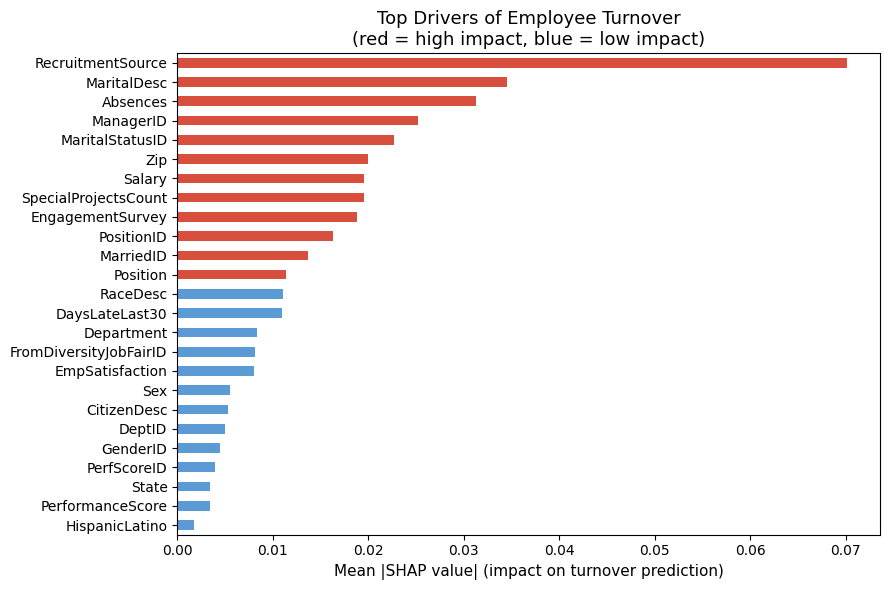

Chart saved: shap_global_summary.png

--- INDIVIDUAL EXPLANATION: Employee index 198 ---
Predicted probability of leaving: 77.0%


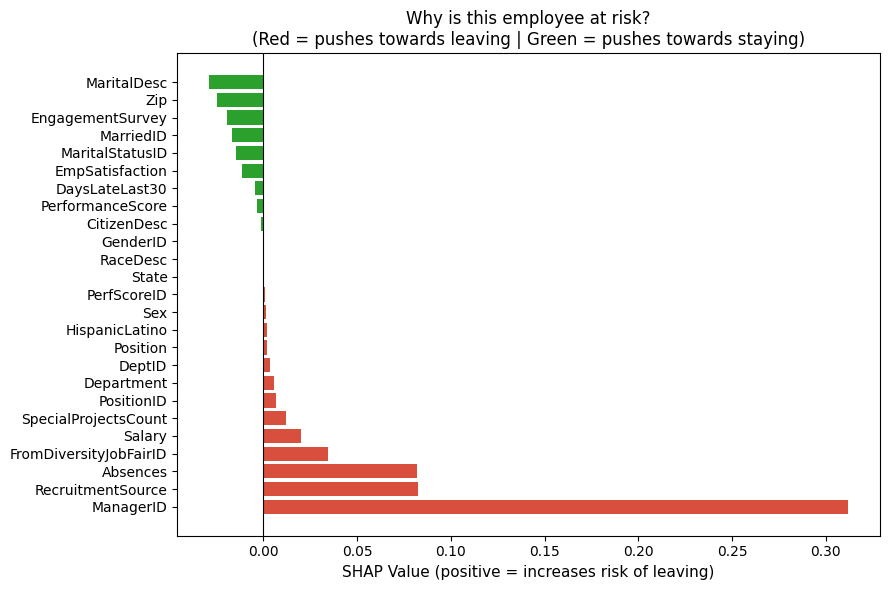

Chart saved: shap_individual_explanation.png


In [7]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Create the SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Robustly extract SHAP values for class 1 (leaving)
if isinstance(shap_values, list):
    # Old API: list of arrays, one per class
    shap_vals_attrition = shap_values[1]
elif hasattr(shap_values, 'values') and shap_values.values.ndim == 3:
    # New API: Explanation object with shape (n_samples, n_features, n_classes)
    shap_vals_attrition = shap_values.values[:, :, 1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_vals_attrition = shap_values[:, :, 1]
else:
    shap_vals_attrition = shap_values

print(f"SHAP values shape: {np.array(shap_vals_attrition).shape}")

# ------- PLOT 1: GLOBAL - Top factors driving turnover -------
mean_abs_shap = np.abs(shap_vals_attrition).mean(axis=0)
feature_importance = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#d94f3d' if v > feature_importance.median() else '#5b9bd5' for v in feature_importance]
feature_importance.plot(kind='barh', color=colors)
plt.xlabel("Mean |SHAP value| (impact on turnover prediction)", fontsize=11)
plt.title("Top Drivers of Employee Turnover\n(red = high impact, blue = low impact)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_global_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: shap_global_summary.png")

# ------- PLOT 2: INDIVIDUAL - Why is THIS specific employee at risk? -------
risk_scores = model.predict_proba(X_test)[:, 1]
highest_risk_idx = np.argmax(risk_scores)
employee_id = X_test.index[highest_risk_idx]

print(f"\n--- INDIVIDUAL EXPLANATION: Employee index {employee_id} ---")
print(f"Predicted probability of leaving: {risk_scores[highest_risk_idx]*100:.1f}%")

employee_shap = shap_vals_attrition[highest_risk_idx]
employee_features = X_test.iloc[highest_risk_idx]

shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Value': employee_features.values,
    'SHAP Impact': employee_shap
}).sort_values('SHAP Impact', ascending=False)

colors = ['#d94f3d' if v > 0 else '#2ca02c' for v in shap_df['SHAP Impact']]
plt.figure(figsize=(9, 6))
plt.barh(shap_df['Feature'], shap_df['SHAP Impact'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("SHAP Value (positive = increases risk of leaving)", fontsize=11)
plt.title("Why is this employee at risk?\n(Red = pushes towards leaving | Green = pushes towards staying)", fontsize=12)
plt.tight_layout()
plt.savefig("shap_individual_explanation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: shap_individual_explanation.png")

## Step 4b: Sanity Check — Is RecruitmentSource really meaningful?
`RecruitmentSource` appears as the top SHAP driver. Before trusting this signal, we verify it directly in the **raw data** by computing the real turnover rate per recruitment channel.
If the rates are very similar across channels, this would suggest the SHAP result is a statistical artefact of the small dataset rather than a genuine causal factor.

--- TURNOVER RATE BY RECRUITMENT SOURCE ---
                         total  left  turnover_rate
RecruitmentSource                                  
Website                     13     1       7.692308
Employee Referral           31     5      16.129032
LinkedIn                    76    18      23.684211
Indeed                      87    21      24.137931
CareerBuilder               23    11      47.826087
Other                        2     1      50.000000
Diversity Job Fair          29    16      55.172414
Google Search               49    30      61.224490
On-line Web application      1     1     100.000000


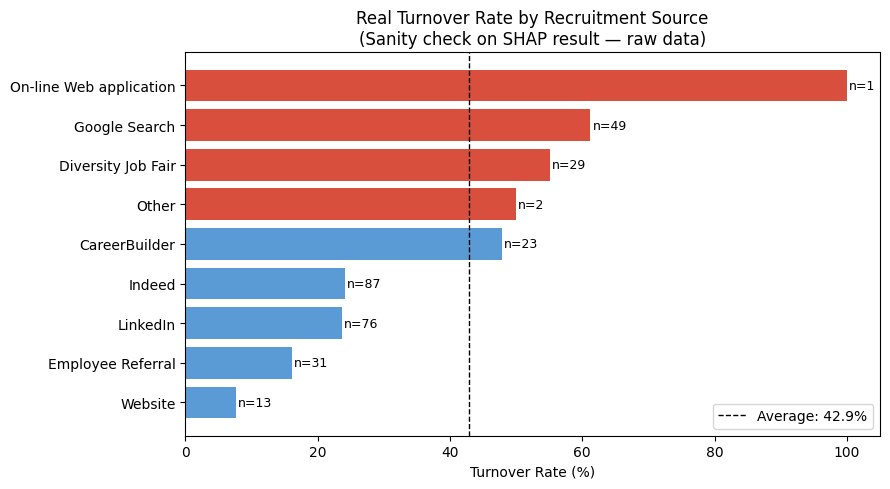


Spread between highest and lowest turnover channel: 92.3%
✅ Large spread — RecruitmentSource is likely a GENUINE signal in the data.


In [8]:
import matplotlib.pyplot as plt

# Use the original raw dataframe (before encoding) for readability
turnover_by_source = (
    df.groupby('RecruitmentSource')['Termd']
    .agg(total='count', left='sum')
    .assign(turnover_rate=lambda x: x['left'] / x['total'] * 100)
    .sort_values('turnover_rate', ascending=True)
)

print("--- TURNOVER RATE BY RECRUITMENT SOURCE ---")
print(turnover_by_source.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d94f3d' if v > turnover_by_source['turnover_rate'].median() else '#5b9bd5'
          for v in turnover_by_source['turnover_rate']]
ax.barh(turnover_by_source.index, turnover_by_source['turnover_rate'], color=colors)
ax.axvline(turnover_by_source['turnover_rate'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"Average: {turnover_by_source['turnover_rate'].mean():.1f}%")
ax.set_xlabel("Turnover Rate (%)")
ax.set_title("Real Turnover Rate by Recruitment Source\n(Sanity check on SHAP result — raw data)")
ax.legend()

# Annotate each bar with the sample size
for i, (idx, row) in enumerate(turnover_by_source.iterrows()):
    ax.text(row['turnover_rate'] + 0.3, i, f"n={int(row['total'])}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("sanity_check_recruitment.png", dpi=150, bbox_inches='tight')
plt.show()

# Interpretation
spread = turnover_by_source['turnover_rate'].max() - turnover_by_source['turnover_rate'].min()
print(f"\nSpread between highest and lowest turnover channel: {spread:.1f}%")
if spread > 20:
    print("✅ Large spread — RecruitmentSource is likely a GENUINE signal in the data.")
elif spread > 10:
    print("⚠️  Moderate spread — RecruitmentSource may be partially meaningful, but treat with caution (small sample sizes).")
else:
    print("❌ Small spread — RecruitmentSource is likely a STATISTICAL ARTEFACT. SHAP overfits on this small dataset.")